<a href="https://colab.research.google.com/github/Yahsakem1/ml_projects/blob/main/walmart_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [ ]:
data = pd.read_csv("Walmart_Sales.csv")
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
data["Store"].value_counts()

,count
Store,
1,143
2,143
3,143
4,143
5,143
6,143
7,143
8,143
9,143


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


#Разделим дату на год, месяц и день

In [ ]:
data["Date"] = pd.to_datetime(data["Date"],format = "%d-%m-%Y")
data["year"] = data["Date"].dt.year
data["month"] = data["Date"].dt.month
data["day"] = data["Date"].dt.day

In [ ]:
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,28
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,5
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,12
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,19


#Посмотрим на сезонные данные

In [ ]:
data["season"] = pd.cut(
    (data["month"] % 12),
    bins=[-1, 2, 5, 8, 11],
    labels=["Winter", "Spring", "Summer", "Autumn"]
)

In [ ]:
data.groupby(["Store","season"])["Weekly_Sales"].mean().loc[1]

/tmp/ipykernel_618/2408176452.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Store","season"])["Weekly_Sales"].mean().loc[1]


,Weekly_Sales
season,
Winter,1.620620e+06
Spring,1.551516e+06
Summer,1.528107e+06
Autumn,1.533847e+06


Добавим 30 дневную скользящую среднюю

Добавим также данные за волатильность за месяц,лаг за прошлую неделю и за прошлый месяц

In [ ]:
data = data.sort_values(by=['Store', 'Date']).reset_index(drop=True)
data['rolling_mean_30D'] = (
    data.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)
data['rolling_std_30D'] = (
    data.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)
data['lag_week'] = (
    data.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(1))
)
data['lag_month'] = (
    data.groupby('Store')['Weekly_Sales']
    .transform(lambda x: x.shift(4))
)
data.dropna(inplace=True)

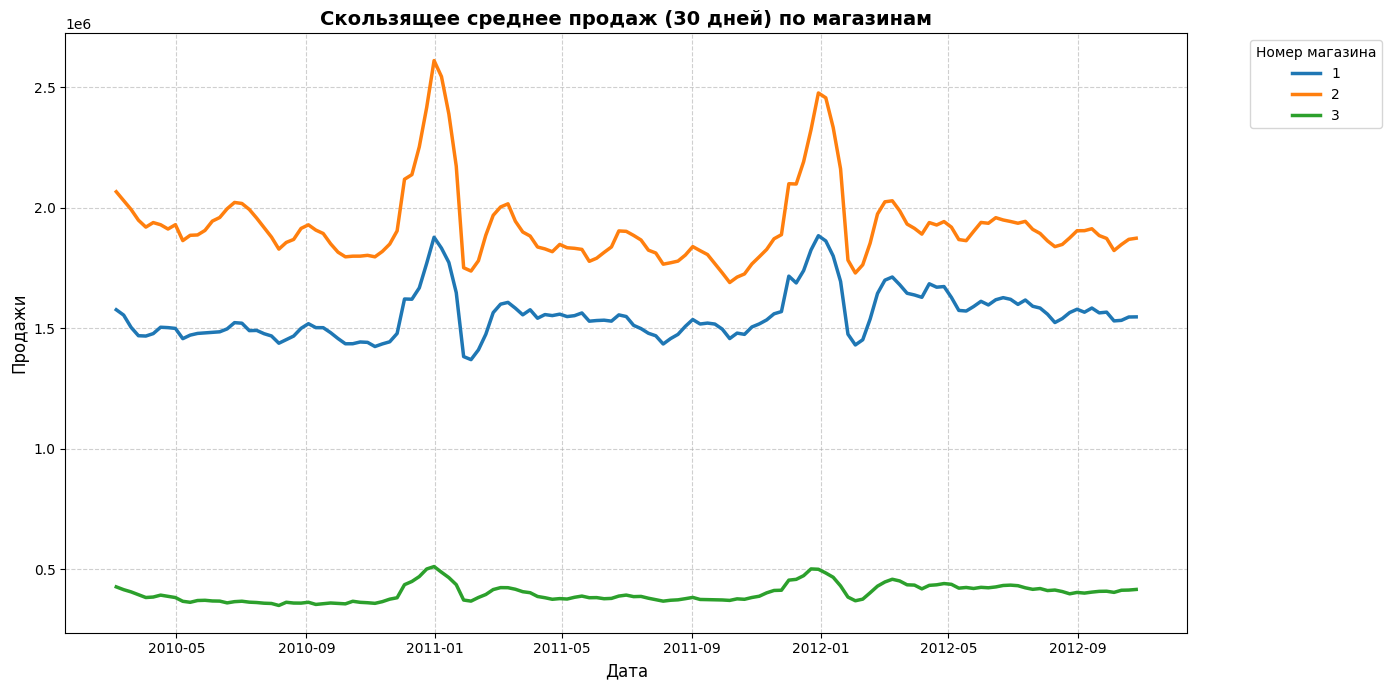

In [ ]:
target_stores = [1, 2, 3]
plot_data = data[data["Store"].isin(target_stores)]
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=plot_data,
    x="Date",
    y="rolling_mean_30D",
    hue="Store",
    linewidth=2.5,
    palette="tab10"
)
plt.title("Скользящее среднее продаж (30 дней) по магазинам", fontsize=14, fontweight="bold")
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Продажи", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Номер магазина", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Видно, что под Новый Год продажи максимальны

Также прожажи очень сильно изменяются от магазина к магазину

Проверим гипотезу, что в начале месяца продажи выше, чем в конце

Выдвинул такую гипотезу из-за возможной свзяи с получением заработной платы

H0 = продажи не отличаются

H1 = продажи выше

a = 0.05

In [ ]:
def get_month_part(day): # Разделим месяц
    if day <= 7:
        return "start"
    elif day <= 21:
        return "middle"
    else:
        return "end"

data["month_part"] = data["day"].apply(get_month_part)

store_comp = data.groupby(["Store", "month_part"])["Weekly_Sales"].mean().unstack()
store_comp = store_comp.dropna(subset=["start", "end"])


t_stat, p_value = stats.ttest_rel(store_comp["start"], store_comp["end"], alternative="greater")

print(f"p-value: {p_value:.5f}")

p-value: 0.24198


Нулевую гипотезу не отвергаем, но посмотрим также графически

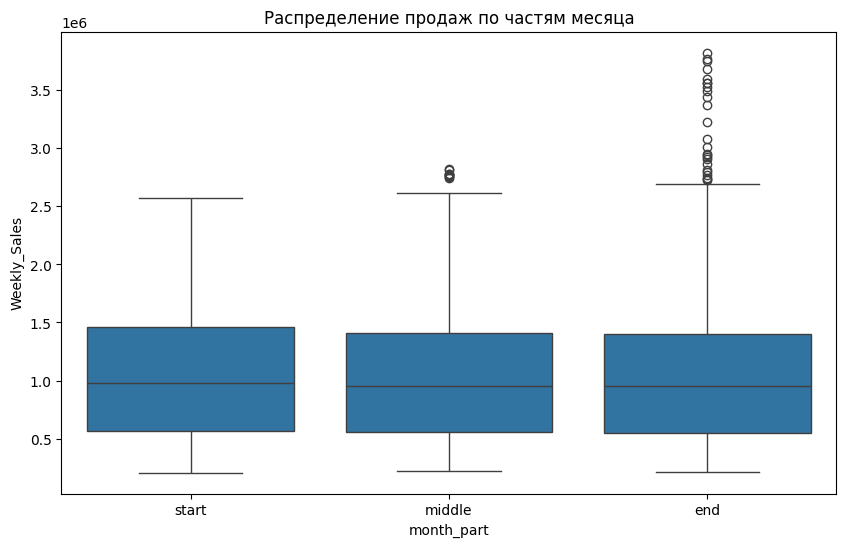

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="month_part", y="Weekly_Sales", data=data,
            order=["start", "middle", "end"])
plt.title('Распределение продаж по частям месяца')
plt.show()



Нулевую гипотезу не отвергаем, продажи в начале месяца никак не отличаются от продаж в конце

Из box_plot можно увидеть, что в end есть большее количество выбросов чем в остальных, думаю что это связано с новым годом

Сделаем матрицу корреляции

<Axes: >

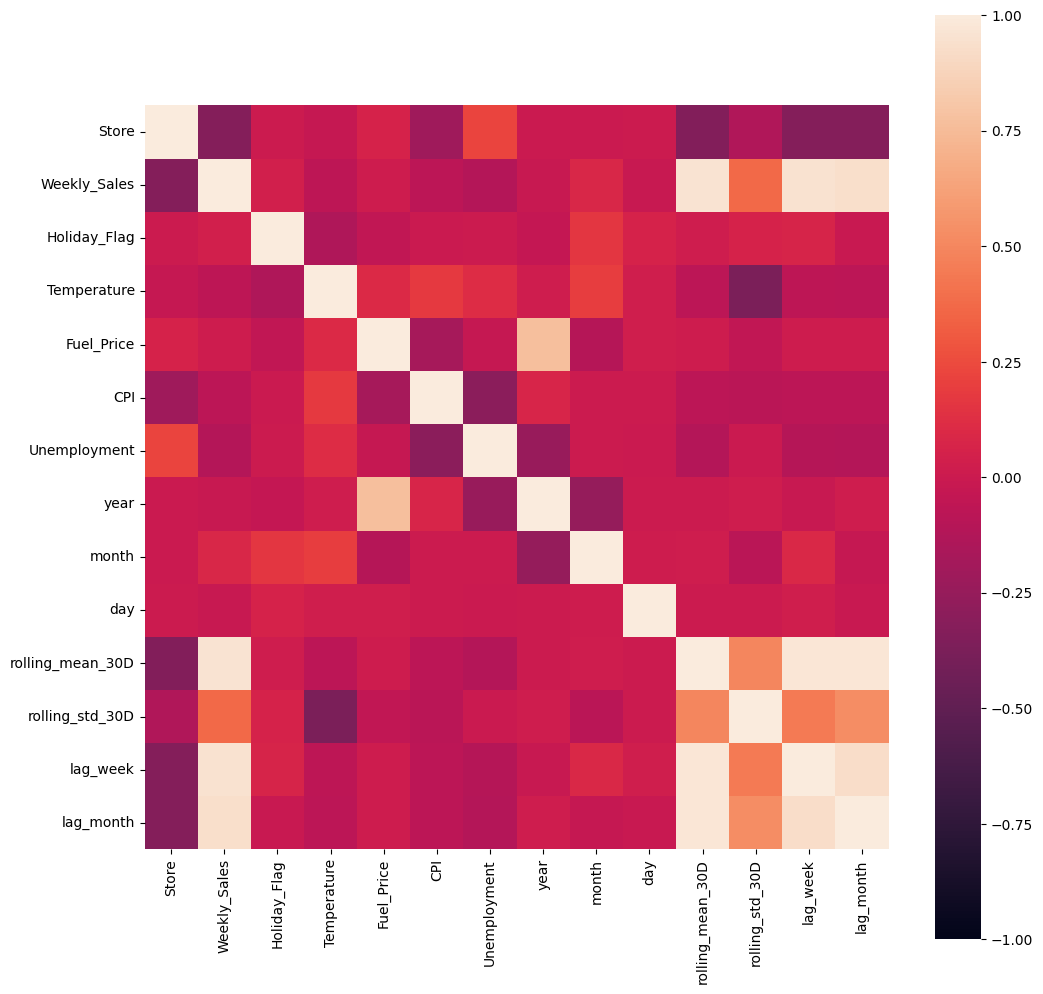

In [ ]:
numeric_features = data.select_dtypes("number").columns
fig = plt.figure(figsize = (12,12))
corr = data[numeric_features].corr()
sns.heatmap(corr,vmax=1.0, vmin=-1.0,square=True  )

Построим box_plot по временам года

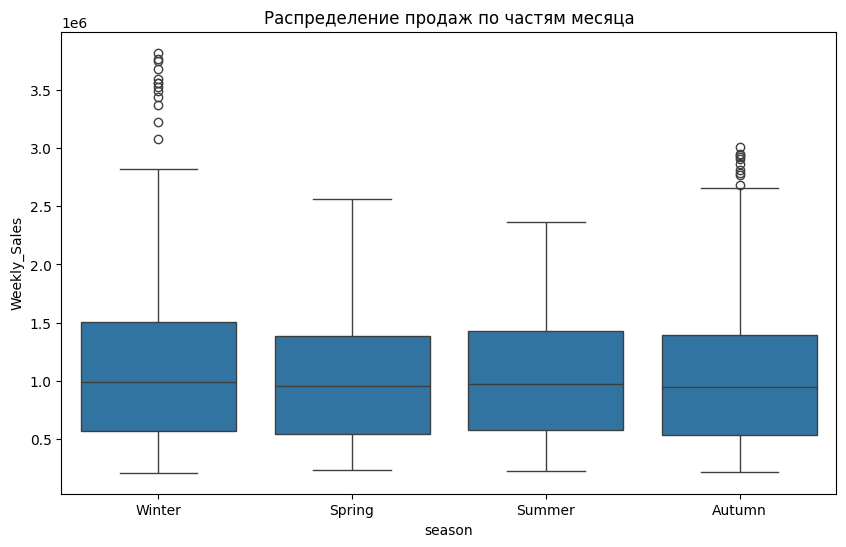

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="season", y="Weekly_Sales", data=data)
plt.title('Распределение продаж по частям месяца')
plt.show()


Есть выбросы осенью, думаю связано с днем благодарения, так как данные Американские

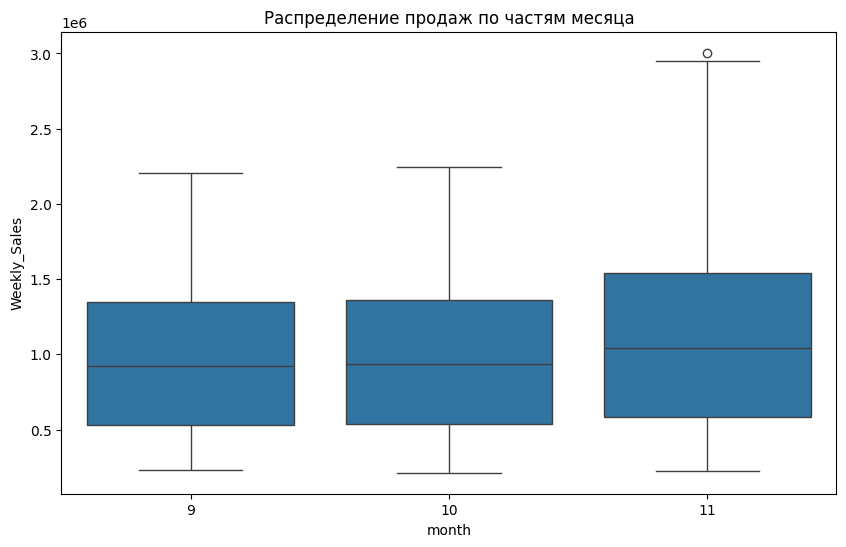

In [ ]:
plt.figure(figsize=(10, 6))
autumn = data.loc[data["season"] == "Autumn"]
sns.boxplot(x="month", y="Weekly_Sales", data = autumn)
plt.title('Распределение продаж по частям месяца')
plt.show()

Да, скорее всего более высокие продажи связаны именно с днем благодарения

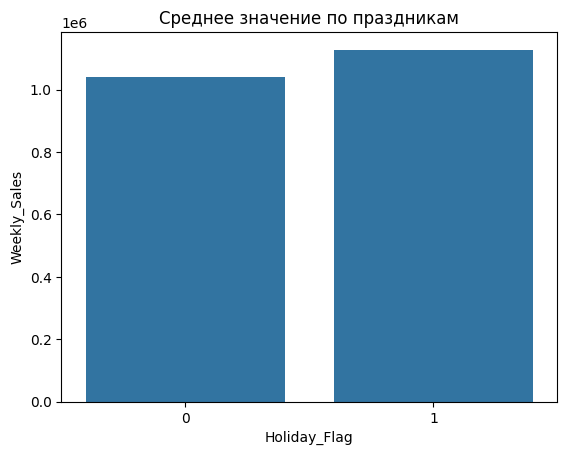

In [ ]:
data_holiday = data.groupby("Holiday_Flag")["Weekly_Sales"].mean().reset_index()
sns.barplot(x = "Holiday_Flag", y = "Weekly_Sales", data = data_holiday)
plt.title("Среднее значение по праздникам")
plt.show()

In [ ]:
data_holiday.iloc[1]["Weekly_Sales"] - data_holiday.iloc[0]["Weekly_Sales"]

np.float64(87290.8915411206)

In [ ]:
87290/data_holiday.iloc[0]["Weekly_Sales"] *100

np.float64(8.385105839394411)

Разница в 90 тысяч, то есть в праздники продажи в среднем на 8% выше.

Посмотрим на распределеение целевой переменной

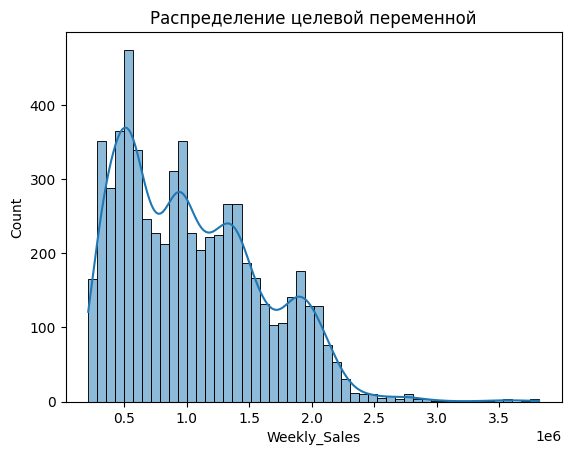

In [ ]:
sns.histplot(data['Weekly_Sales'], kde=True, bins=50)
plt.title("Распределение целевой переменной")
plt.show()

Видно что есть тяжелый правый хвост, похоже на логнормальное распределение

Посмотрим на общий тренд

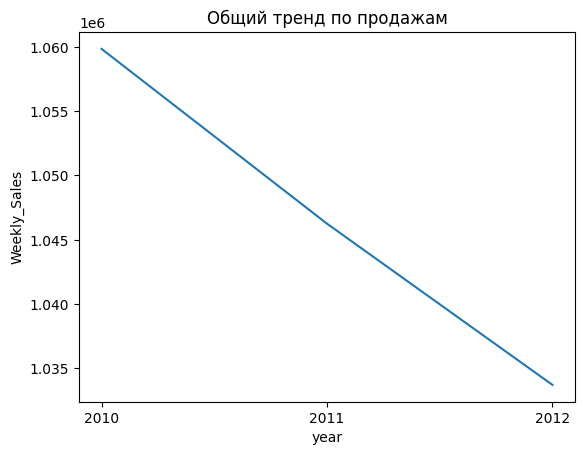

In [ ]:
data_year = data.groupby("year")["Weekly_Sales"].mean().reset_index()
sns.lineplot(x = "year", y = "Weekly_Sales", data = data_year)
plt.xticks(data_year['year'].unique())
plt.title("Общий тренд по продажам")
plt.show()

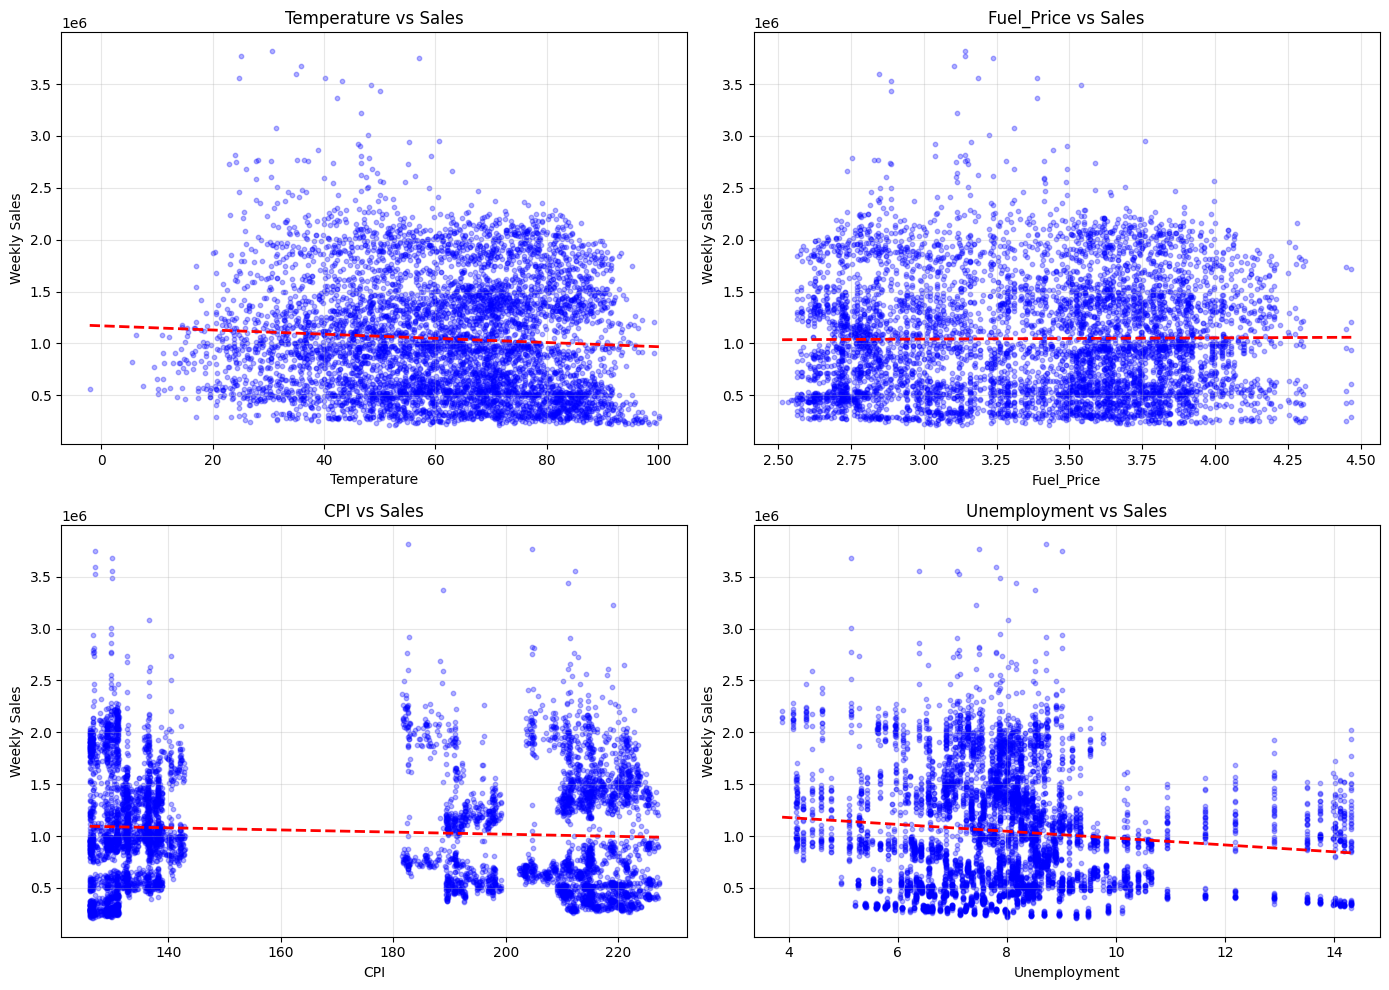

In [ ]:
features = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
target = "Weekly_Sales"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feature in enumerate(features):
    ax = axes[i]
    ax.scatter(data[feature], data[target], alpha=0.3, s=10, color="blue")
    z = np.polyfit(data[feature], data[target], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(data[feature])
    ax.plot(x_sorted, p(x_sorted), "r--", linewidth=2)
    ax.set_xlabel(feature)
    ax.set_ylabel("Weekly Sales")
    ax.set_title(f"{feature} vs Sales")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Перейдем к обучению моделей

In [ ]:
train = data[data["Date"] <= "2012-04-30"].copy().sort_values("Date").drop("Date",axis = 1)
#val = data[(data["Date"] >= "2012-01-01") & (data["Date"] <= "2012-04-30")].copy().drop("Date",axis = 1)
test = data[data["Date"] > "2012-04-30"].copy().drop("Date",axis = 1)
cat_features = ["season","month_part"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_array_train = encoder.fit_transform(train[cat_features])
#encoded_array_val = encoder.transform(val[cat_features])
encoded_array_test = encoder.transform(test[cat_features])
encoded_train = pd.DataFrame(encoded_array_train, columns=encoder.get_feature_names_out(cat_features))
encoded_test = pd.DataFrame(encoded_array_test, columns=encoder.get_feature_names_out(cat_features))
#encoded_val = pd.DataFrame(encoded_array_val, columns=encoder.get_feature_names_out(cat_features))
train = pd.concat([
    train.drop(columns=cat_features).reset_index(drop=True),
    encoded_train.reset_index(drop=True)
], axis=1)

#val = pd.concat([
#    val.drop(columns=cat_features).reset_index(drop=True),
#    encoded_val.reset_index(drop=True)
#], axis=1)

test = pd.concat([
    test.drop(columns=cat_features).reset_index(drop=True),
    encoded_test.reset_index(drop=True)
], axis=1)
train

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,day,...,rolling_std_30D,lag_week,lag_month,season_Autumn,season_Spring,season_Summer,season_Winter,month_part_end,month_part_middle,month_part_start
0,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5,...,112353.415114,1409727.59,1643690.90,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,17,783300.05,0,31.58,2.681,126.578286,6.548,2010,3,5,...,38026.537053,749549.55,789036.02,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,34,918295.79,0,42.65,2.654,126.578286,9.521,2010,3,5,...,39701.760522,905756.13,956228.96,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,13,1939980.43,0,40.65,2.681,126.578286,8.316,2010,3,5,...,90690.506208,1817850.32,1967220.53,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,16,444181.85,0,27.92,2.620,189.669505,7.039,2010,3,5,...,15265.166363,443242.17,477409.30,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5080,15,527402.62,0,41.57,4.163,137.978133,8.150,2012,4,27,...,55912.758762,534780.57,557547.25,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5081,14,1784029.95,0,53.20,4.004,190.868006,8.567,2012,4,27,...,239608.863999,1875686.44,1905033.01,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5082,19,1285897.24,0,42.45,4.163,137.978133,8.150,2012,4,27,...,164437.682471,1255087.26,1327139.35,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5083,1,1468928.37,0,67.23,3.814,221.617937,7.143,2012,4,27,...,160788.799316,1521577.87,1649604.63,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Сначала попробуем сделать одну общую модель для всех магазинов

Также попробуем сделать кластеризацию магазинов, а уже потом предсказывать



In [ ]:
!pip install catboost

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.cluster import KMeans

Обучаем модели с OHE кодировкой

In [ ]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
model = LGBMRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=30,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print("Лучшие параметры:", search.best_params_)
print("CV MAE:", -search.best_score_)
best_model = search.best_estimator_
print("Test MAE:", mean_absolute_error(y_test, best_model.predict(X_test)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2138
[LightGBM] [Info] Number of data points in the train set: 5085, number of used features: 20
[LightGBM] [Info] Start training from score 1047815.487518
Лучшие параметры: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
CV MAE: 77113.70862937768
Test MAE: 42018.16923784146


In [ ]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
model_cat = CatBoostRegressor(random_state=42, verbose=0)
param_grid = {
    "iterations": [300, 500, 1000],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
    "bagging_temperature": [0, 0.5, 1],
}
search_cat = RandomizedSearchCV(
    model_cat,
    param_distributions=param_grid,
    n_iter=30,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
search_cat.fit(X_train, y_train)
print("Лучшие параметры:", search_cat.best_params_)
print("CV MAE:", -search_cat.best_score_)
best_model_cat = search_cat.best_estimator_
print("Test MAE:", mean_absolute_error(y_test, best_model_cat.predict(X_test)))

Лучшие параметры: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 1000, 'depth': 6, 'bagging_temperature': 0}
CV MAE: 76236.05860860067
Test MAE: 40426.18334940539


In [ ]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
model_xgb = XGBRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 5],
}
search_xgb = RandomizedSearchCV(
    model_xgb,
    param_distributions=param_grid,
    n_iter=30,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
search_xgb.fit(X_train, y_train)
print("Лучшие параметры:", search_xgb.best_params_)
print("CV MAE:", -search_xgb.best_score_)
best_model_xgb = search_xgb.best_estimator_
print("Test MAE:", mean_absolute_error(y_test, best_model_xgb.predict(X_test)))

Лучшие параметры: {'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
CV MAE: 76786.52940894334
Test MAE: 42625.6706741453


Попробуем по другому кодировать категориальные признаки

In [ ]:
encoder = OrdinalEncoder(categories=[
    ["Winter", "Spring", "Summer", "Autumn"],
    ["start", "middle", "end"]
])
train = data[data["Date"] <= "2012-04-30"].copy().sort_values("Date").drop("Date",axis = 1)
test = data[data["Date"] > "2012-04-30"].copy().drop("Date",axis = 1)
train[cat_features] = encoder.fit_transform(train[cat_features])
test[cat_features] = encoder.transform(test[cat_features])

In [ ]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
params_cat_final = search_cat.best_params_
model_cat_final = CatBoostRegressor(**params_cat_final,random_state=42, verbose=0)
model_cat_final.fit(X_train, y_train)
print("Test MAE:", mean_absolute_error(y_test, model_cat_final.predict(X_test)))

Test MAE: 39582.156424194116


Результат улучшился

Попробуем кластеризировать магазины и добавить кластеры как отдельный признак

In [83]:
store_features = data.groupby("Store").agg(
    mean_sales=("Weekly_Sales", "mean"),
    std_sales=("Weekly_Sales", "std"),
    mean_temp=("Temperature", "mean"),
    mean_unemployment=("Unemployment", "mean"),
    mean_cpi=("CPI", "mean")
).reset_index()
# encoder = OrdinalEncoder(categories=[
#     ["Winter", "Spring", "Summer", "Autumn"],
#     ["start", "middle", "end"]
# ])
# data[cat_features] = encoder.fit_transform(data[cat_features])
scaler = StandardScaler()
X_cluster = scaler.fit_transform(store_features.drop("Store", axis=1))

kmeans = KMeans(n_clusters=5, random_state=42)
store_features["cluster"] = kmeans.fit_predict(X_cluster)

data_clust = data.merge(store_features[["Store", "cluster"]], on="Store")
train = data_clust[data_clust["Date"] <= "2012-04-30"].copy().sort_values("Date").drop("Date",axis = 1)
test = data_clust[data_clust["Date"] > "2012-04-30"].copy().drop("Date",axis = 1)

In [ ]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
params_cat_final = search_cat.best_params_
model_cat_final = CatBoostRegressor(**params_cat_final,random_state=42, verbose=0)
model_cat_final.fit(X_train, y_train)
print("Test MAE:", mean_absolute_error(y_test, model_cat_final.predict(X_test)))

Попробуем также добавить агрегаты по магазинам (среднее и std), важно делать только по трейну, иначе data leakage

In [86]:
store_stats = train.groupby("Store")["Weekly_Sales"].agg(["mean", "std"]).rename(
    columns={"mean": "store_mean_sales", "std": "store_std_sales"}
)
train = train.merge(store_stats, on="Store")
test = test.merge(store_stats, on="Store")

In [88]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
model = LGBMRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=100,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print("Лучшие параметры:", search.best_params_)
print("CV MAE:", -search.best_score_)
best_model = search.best_estimator_
print("Test MAE:", mean_absolute_error(y_test, best_model.predict(X_test)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2228
[LightGBM] [Info] Number of data points in the train set: 5085, number of used features: 18
[LightGBM] [Info] Start training from score 1047815.487518
Лучшие параметры: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
CV MAE: 73475.5961172052
Test MAE: 39277.82425765071


In [89]:
X_train = train.drop("Weekly_Sales",axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales",axis = 1)
y_test = test["Weekly_Sales"]
model_xgb = XGBRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 5],
}
search_xgb = RandomizedSearchCV(
    model_xgb,
    param_distributions=param_grid,
    n_iter=100,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
search_xgb.fit(X_train, y_train)
print("Лучшие параметры:", search_xgb.best_params_)
print("CV MAE:", -search_xgb.best_score_)
best_model_xgb = search_xgb.best_estimator_
print("Test MAE:", mean_absolute_error(y_test, best_model_xgb.predict(X_test)))

Лучшие параметры: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
CV MAE: 72369.31753645217
Test MAE: 37196.85990331197


In [ ]:
#{'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

In [90]:
#Для catboost уберем агрегаты
cols = ["store_mean_sales", "store_std_sales","Weekly_Sales"]
X_train = train.drop(cols,axis = 1)
y_train = train["Weekly_Sales"]
X_test = test.drop(cols,axis = 1)
y_test = test["Weekly_Sales"]
model_cat = CatBoostRegressor(random_state=42, verbose=0)
param_grid = {
    "iterations": [ 500, 1000],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
    "bagging_temperature": [0, 0.5, 1],
}
search_cat = RandomizedSearchCV(
    model_cat,
    param_distributions=param_grid,
    n_iter=15,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)
search_cat.fit(X_train, y_train)
print("Лучшие параметры:", search_cat.best_params_)
print("CV MAE:", -search_cat.best_score_)
best_model_cat = search_cat.best_estimator_
print("Test MAE:", mean_absolute_error(y_test, best_model_cat.predict(X_test)))

Лучшие параметры: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 6, 'bagging_temperature': 0.5}
CV MAE: 76272.23302962756
Test MAE: 41563.322349660644


In [91]:
params = {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 6, 'bagging_temperature': 1} # Парамерты с прошлого запуска
model_cat = CatBoostRegressor(**params,random_state=42, verbose=0)
model_cat.fit(X_train,y_train)
preds = model_cat.predict(X_test)
print(mean_absolute_error(y_test,preds))

39761.303962392136


In [93]:
X_test_no_cat = test.drop("Weekly_Sales",axis = 1)

Посмотрим корреляцию моделей для возможного ансамбля

In [94]:
pred_lgb = best_model.predict(X_test_no_cat)
pred_xgb = best_model_xgb.predict(X_test_no_cat)
pred_cat = model_cat.predict(X_test)

print(np.corrcoef([pred_lgb, pred_xgb, pred_cat]))

[[1.         0.99870329 0.99730096]
 [0.99870329 1.         0.99814962]
 [0.99730096 0.99814962 1.        ]]


Ансамбль строить нет смысла

Посмотрим какая модель лучше на каждом магазине и на каждом кластере

In [95]:
results = []
for store in test["Store"].unique():
    mask = test["Store"] == store
    results.append({
        "Store": store,
        "MAE_lgb": mean_absolute_error(y_test[mask], pred_lgb[mask]),
        "MAE_xgb": mean_absolute_error(y_test[mask], pred_xgb[mask]),
        "MAE_cat": mean_absolute_error(y_test[mask], pred_cat[mask]),
    })

pd.DataFrame(results).set_index("Store")


,MAE_lgb,MAE_xgb,MAE_cat
Store,,,
1,41807.543835,38723.283462,35625.644502
2,53011.616079,40402.836154,52606.007003
3,20359.438190,23888.306106,20718.263485
4,61306.446281,41292.480577,53647.486459
5,20147.654968,25436.320577,18363.081477
6,63039.460171,59875.097885,54949.466781
7,31624.202601,36206.300865,41683.891645
8,27049.410570,26971.814615,26995.109309
9,25162.017162,24494.837019,19736.626927


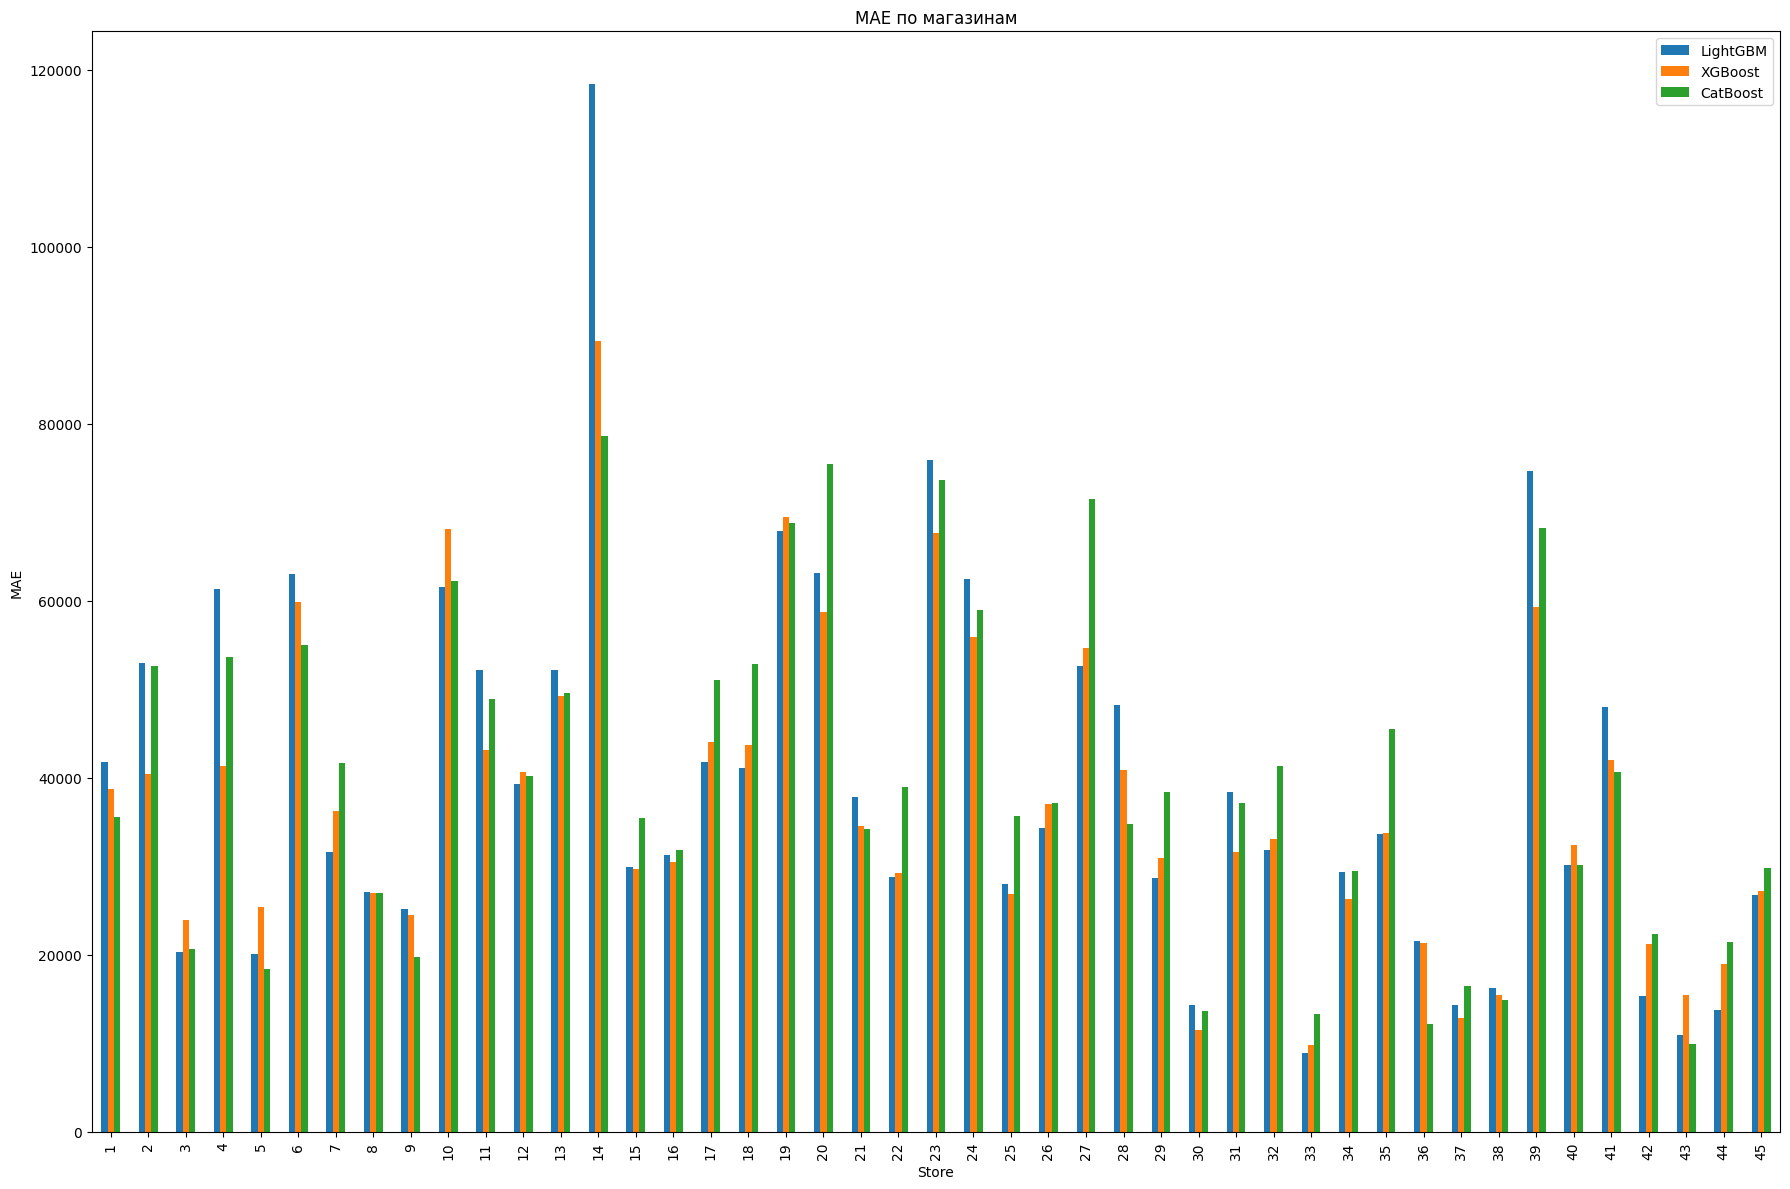

In [100]:
df_results = pd.DataFrame(results).set_index("Store")

df_results.plot(kind="bar", figsize=(18, 12))
plt.title("MAE по магазинам")
plt.xlabel("Store")
plt.ylabel("MAE")
plt.legend(["LightGBM", "XGBoost", "CatBoost"])
plt.tight_layout()
plt.show()

In [103]:
results = []
for cluster in test["cluster"].unique():
    mask = test["cluster"] == cluster
    results.append({
        "cluster": cluster,
        "MAE_lgb": mean_absolute_error(y_test[mask], pred_lgb[mask]),
        "MAE_xgb": mean_absolute_error(y_test[mask], pred_xgb[mask]),
        "MAE_cat": mean_absolute_error(y_test[mask], pred_cat[mask]),
    })

pd.DataFrame(results).set_index("cluster")

,MAE_lgb,MAE_xgb,MAE_cat
cluster,,,
2,61033.966257,52875.126298,57382.391499
4,22604.094484,22628.634441,20297.815526
0,37651.468465,37626.965752,42249.464596
3,34597.152373,32333.495016,29961.359457
1,11697.460891,15471.756739,15221.183472


In [104]:
test.groupby("cluster")["Weekly_Sales"].mean()

,Weekly_Sales
cluster,
0,9.340081e+05
1,4.845043e+05
2,1.737926e+06
3,8.867509e+05
4,5.199691e+05


Исходя из кластеров видим, что

cat - лучший в кластерах 4 и 3

xgb - лучший в 2 и 0

lgb - лучший в 1

Попробуем распределить по кластерам и посмотрим mae

In [106]:
best_per_cluster = {
    0: pred_xgb,
    1: pred_lgb,
    2: pred_xgb,
    3: pred_cat,
    4: pred_cat,
}

final_pred = np.zeros(len(y_test))
for cluster_id, preds in best_per_cluster.items():
    mask = test["cluster"] == cluster_id
    final_pred[mask] = preds[mask]

print("Cluster-based MAE:", mean_absolute_error(y_test, final_pred))

Cluster-based MAE: 36372.73000248968


In [108]:
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_test, final_pred))
print(root_mean_squared_error(y_test, final_pred))

0.9902518185178778
52836.95801728239


<Axes: title={'center': 'MAE по месяцам'}, xlabel='month'>

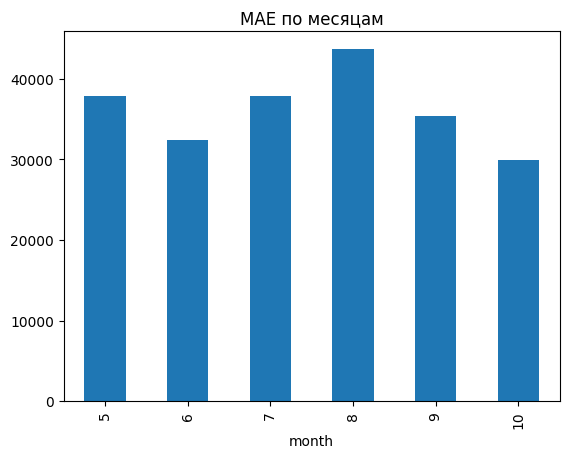

In [109]:
test["pred"] = final_pred
test["mae"] = np.abs(test["Weekly_Sales"] - test["pred"])
test.groupby("month")["mae"].mean().plot(kind="bar", title="MAE по месяцам")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

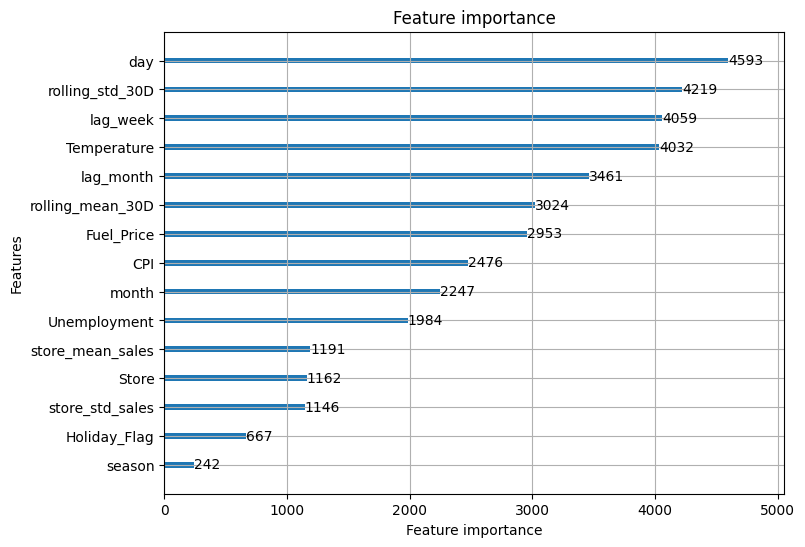

In [110]:
import lightgbm as lgb
lgb.plot_importance(best_model, max_num_features=15, figsize=(8, 6))


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

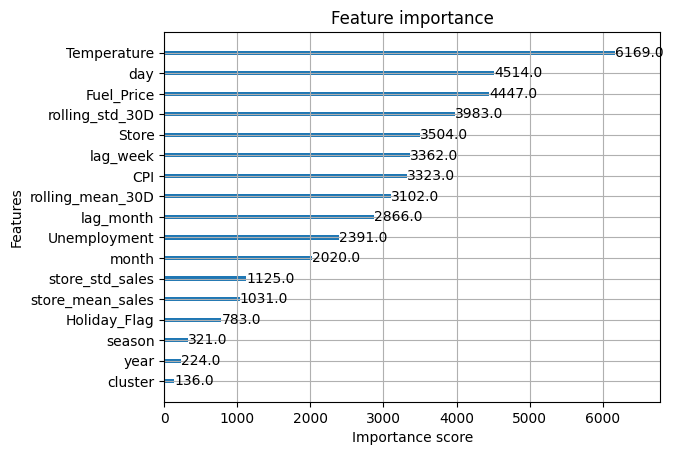

In [112]:
import xgboost as xgb
xgb.plot_importance(best_model_xgb)

В итоге получилось:

MAE = 36372

r2_score = 0.99

RMSE = 52836

Важно отметить что разница в ошибке на cv и тесте есть потому что выборка в тесте не идеальна и не содержит месяца с наиболее аномальными праздниками(ноябрь и декабрь).